In [2]:
# import all the necessary libraries
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd

In [98]:
data = pd.read_csv("C://Users/wanik/SINDY/ROM_data.csv")
data = data.values
omega = 1.131
t = data[:,0]
tcat = np.expand_dims(t,axis=1)
x = data[:,1:5]

x = np.hstack((x, omega * tcat))
x0 = [0.0, 0, 0, 0, 0]

In [105]:
# The feature names of the columns of y
feature_names = ['x1', 'x2',"q1","q2", "omega t"]

# Which feature library to use

poly_lib = ps.PolynomialLibrary(degree=3)
fourier_lib = ps.FourierLibrary(n_frequencies=3)

inputs_temp = np.tile([0, 1, 2, 3, 4], 2)
inputs_per_library = np.reshape(inputs_temp, (2,5))

inputs_per_library[0,4] = 0
inputs_per_library[1,0] = 4
inputs_per_library[1,1] = 4
inputs_per_library[1,2] = 4
inputs_per_library[1,3] = 4
inputs_per_library[1,4] = 4

print(inputs_per_library)

generalized_library = ps.GeneralizedLibrary(
    [poly_lib, fourier_lib],
inputs_per_library = inputs_per_library)

# Differentiation method
differentiation_method = ps.SmoothedFiniteDifference()


# Optimizer
opt = ps.STLSQ(threshold=0.2)

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = generalized_library,
               feature_names=feature_names, 
              optimizer=opt)

# Fitting the model to the training data
model.fit(x,t=t)

# Print the model
model.print()
model.get_feature_names()

[[0 1 2 3 0]
 [4 4 4 4 4]]
(x1)' = 0.000
(x2)' = 0.000
(q1)' = 0.999 q2
(q2)' = -1.431 q1 + 0.285 q2 + -0.284 q1^2 q2
(omega t)' = 1.131 1


C:\Users\wanik\anaconda3\lib\site-packages\pysindy\optimizers\stlsq.py:201: UserWarning: Sparsity parameter is too big (0.2) and eliminated all coefficients
  warnings.warn(


['1',
 'x1',
 'x2',
 'q1',
 'q2',
 'x1^2',
 'x1 x2',
 'x1 q1',
 'x1 q2',
 'x2^2',
 'x2 q1',
 'x2 q2',
 'q1^2',
 'q1 q2',
 'q2^2',
 'x1^3',
 'x1^2 x2',
 'x1^2 q1',
 'x1^2 q2',
 'x1 x2^2',
 'x1 x2 q1',
 'x1 x2 q2',
 'x1 q1^2',
 'x1 q1 q2',
 'x1 q2^2',
 'x2^3',
 'x2^2 q1',
 'x2^2 q2',
 'x2 q1^2',
 'x2 q1 q2',
 'x2 q2^2',
 'q1^3',
 'q1^2 q2',
 'q1 q2^2',
 'q2^3',
 'sin(1 omega t)',
 'cos(1 omega t)',
 'sin(2 omega t)',
 'cos(2 omega t)',
 'sin(3 omega t)',
 'cos(3 omega t)']

In [100]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

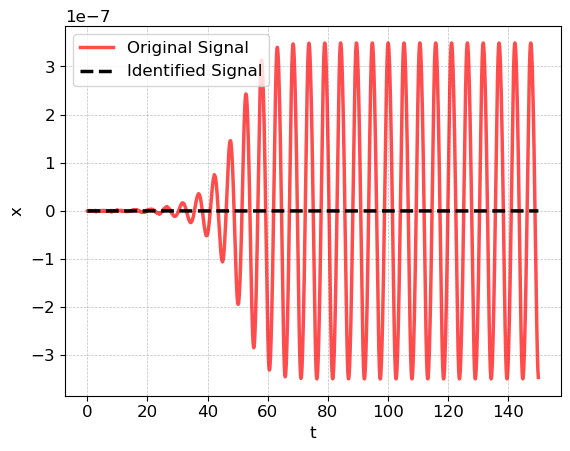

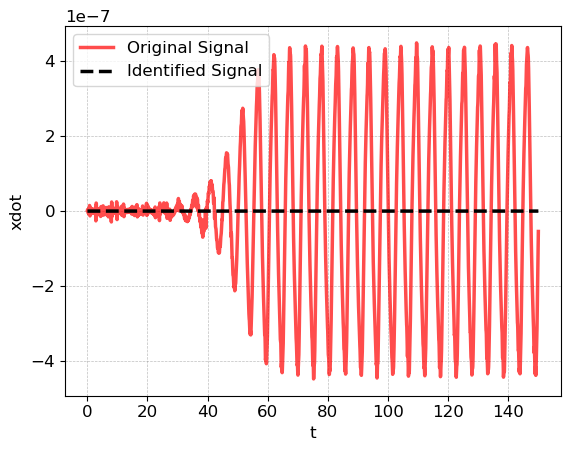

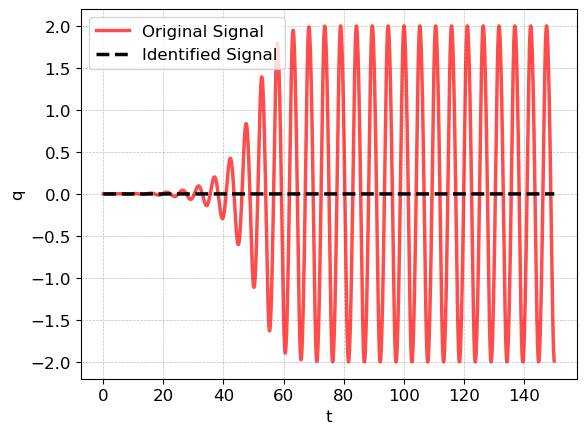

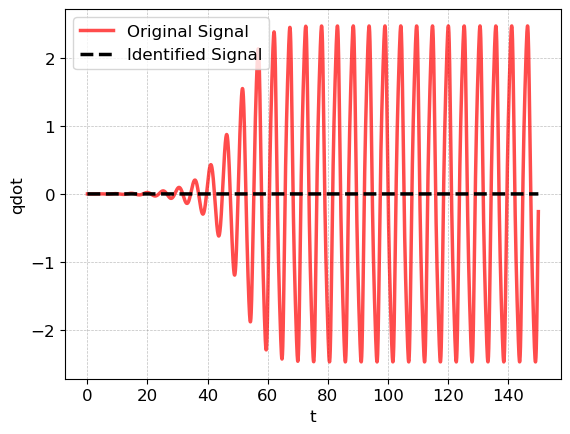

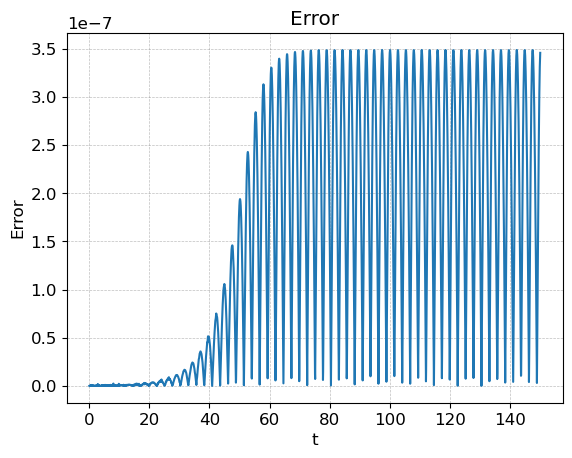

In [101]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.show()

# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.show()

# lift
plt.plot(t,x[:,2],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,2],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("q")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

plt.show()

# velocity
plt.plot(t,x[:,3],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,3],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("qdot")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

plt.show()

# Error
plt.plot(t, np.abs(sim[:,0]-x[:,0]))
plt.title("Error")
plt.xlabel("t")
plt.ylabel("Error")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

plt.show()

In [104]:
from sklearn.metrics import r2_score, mean_squared_error
r2_score(x[:,1],sim[:,1])

-9.452544278110153e-05